### **TRABAJO PRÁCTICO N° 3: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 3**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

En este ejercicio deben construir una Red Neuronal Convolucional-Recurrente (CRNN) para reconocer comandos de voz a partir de grabaciones de audio de un segundo. El dataset contiene grabaciones pronunciadas por muchos hablantes distintos en condiciones acusticas reales (ruido de fondo, variaciones de micrófono), lo que hace que el modelado temporal de la RNN tenga valor real: comandos como down o stop son secuencias fon ́eticas con estructura temporal que una red sin memoria no puede capturar correctamente.

La arquitectura sigue un esquema many-to-one: la CNN procesa cada ventana temporal del espectrograma de forma independiente y produce un vector de características. la secuencia de esos vectores entra a la RNN, que modela cómo los patrones acústicos evolucionan en el tiempo. el  ́ultimo estado oculto se clasifica con una capa densa.

Reducción del problema: Si el entrenamiento completo resulta demasiado pesado para los recursos disponibles, pueden trabajar con un subconjunto de 4 a 6 clases (ej. yes, no, stop, go). Deben justificar la selección en el informe. Se recomienda guardar checkpoints regularmente para poder retomar el entrenamiento ante interrupciones.


#### Variables del conjunto de datos  
**Variables explicativas (features):** - Archivos de audio en formato WAV de 1 segundo de duración, con una frecuencia de muestreo de 16,000 Hz (16 kHz).
 
**Variable objetivo (target):** - Clasificación multiclase (10 clases independientes) para diferenciar entre los comandos de voz sugeridos: 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up' y 'yes'.

#### Librerias

In [1]:
!pip install librosa


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install gdown


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Librerías
import pandas as pd
import seaborn as sns
import optuna
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
#import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

In [4]:
import numpy as np
import librosa 

In [5]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from IPython import display

In [6]:
import shutil  # borra carpetas completas

Fijar una semilla aleatoria al inicio de cada experimento para que los resultados sean reproducibles. Esto incluye las semillas de Python, NumPy y el framework de deep learning utilizado:

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

Para comenzar con el desarrollo, cargamos el dataset a través del enlace de Google Drive: "https://drive.google.com/file/d/1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4/view". Descargamos desde el Drive el dataset de los audios en formato zip, lo descomprimimos y lo almacenamos en la carpeta "problema_3/dataset_problema3":

In [8]:
# ID de tu archivo de Drive
file_id = '1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'dataset_audios.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'problema_3/dataset_problema3'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4
From (redirected): https://drive.google.com/uc?id=1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4&confirm=t&uuid=3d392f18-f62d-4f60-8e79-2b9c38ff3e36
To: c:\Users\Usuario\cnn-rnn-objectdetection-deeplearning\problema_3\dataset_audios.zip
100%|██████████| 2.42G/2.42G [07:09<00:00, 5.63MB/s]


Clases sugeridas (10): yes, no, up, down, left, right, on, off, stop, go

In [9]:
DATA_PATH = 'problema_3/dataset_problema3' 
comandos_objetivo = ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes', 'on', 'off']
archivos_control = ['validation_list.txt', 'testing_list.txt']

for elemento in os.listdir(DATA_PATH):
    ruta_completa = os.path.join(DATA_PATH, elemento)
    
    # Borramos carpetas de palabras que no nos interesen
    if os.path.isdir(ruta_completa) and (elemento not in comandos_objetivo):
        shutil.rmtree(ruta_completa)
    # Borramos archivos de texto que no sean las listas de partición oficiales
    elif os.path.isfile(ruta_completa) and (elemento not in archivos_control):
        os.remove(ruta_completa)

In [10]:
commands = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
print("Carpetas de comandos sugeridos:", commands)

Carpetas de comandos sugeridos: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']


### 3. Preparación del audio
---

#### División del dataset

Dividimos el dataset en conjuntos de entrenamiento, validación y prueba utilizando una proporción de 80:10:10

In [11]:
test_list_oficial = []
val_list_oficial = []

with open(os.path.join(DATA_PATH, 'testing_list.txt'), 'r') as f:
    lineas_test = f.readlines()
    for line in lineas_test:
        test_list_oficial.append(line)

with open(os.path.join(DATA_PATH, 'validation_list.txt'), 'r') as f:
    lineas_val = f.readlines()
    for line in lineas_val:
        val_list_oficial.append(line)

train_files = []
val_files = []
test_files = []

# Recorremos las carpetas para armar los conjuntos definitivos
for label in commands:
    label_dir = os.path.join(DATA_PATH, label)
    for fname in os.listdir(label_dir):
        # Creamos la ruta relativa con '\n' para que coincida con el .txt
        rel_path_con_salto = f"{label}/{fname}\n"
        full_path = os.path.join(label_dir, fname)
        # Evaluamos la pertenencia usando la cadena con el salto de línea incorporado
        if rel_path_con_salto in test_list_oficial:
            test_files.append(full_path)
        elif rel_path_con_salto in val_list_oficial:
            val_files.append(full_path)
        else:
            train_files.append(full_path)

print('Training set size:', len(train_files))
print('Validation set size:', len(val_files))
print('Test set size:', len(test_files))

Training set size: 30769
Validation set size: 3703
Test set size: 4074


#### Función de carga y normalización de los audios

Esta función se encarga de cargar el audio a 16kHz asegurando que dure exactamente un segundo. aquellos audios que duren menos que este lapso de tiempo, se aplicara padding o truncado.

In [12]:
def cargar_onda_y_etiqueta(file_path):
    '''
    Esta función carga el audio a 16kHz y asegura que dure exactamente 1 segundo (16,000 muestras) mediante padding o truncado.
    '''
    audio, sr = librosa.load(file_path, sr=16000)              # Fija la frecuencia en 16000 muestras
    if len(audio) < 16000:                                     # Si dura menos de un segundo, aplica padding con ceros al final
        audio = np.pad(audio, (0, 16000 - len(audio)), mode='constant')
    elif len(audio) > 16000:                                   # Si dura más de un segundo, trunca el audio
        audio = audio[:16000]
        
    # Extraer la etiqueta normalizando la ruta
    ruta_normalizada = os.path.normpath(file_path)
    label = ruta_normalizada.split(os.path.sep)[-2]
    
    return audio, label

Visualizamos las primeras 9 ondas de audio (Waveform) del dataset de entrenamiento:

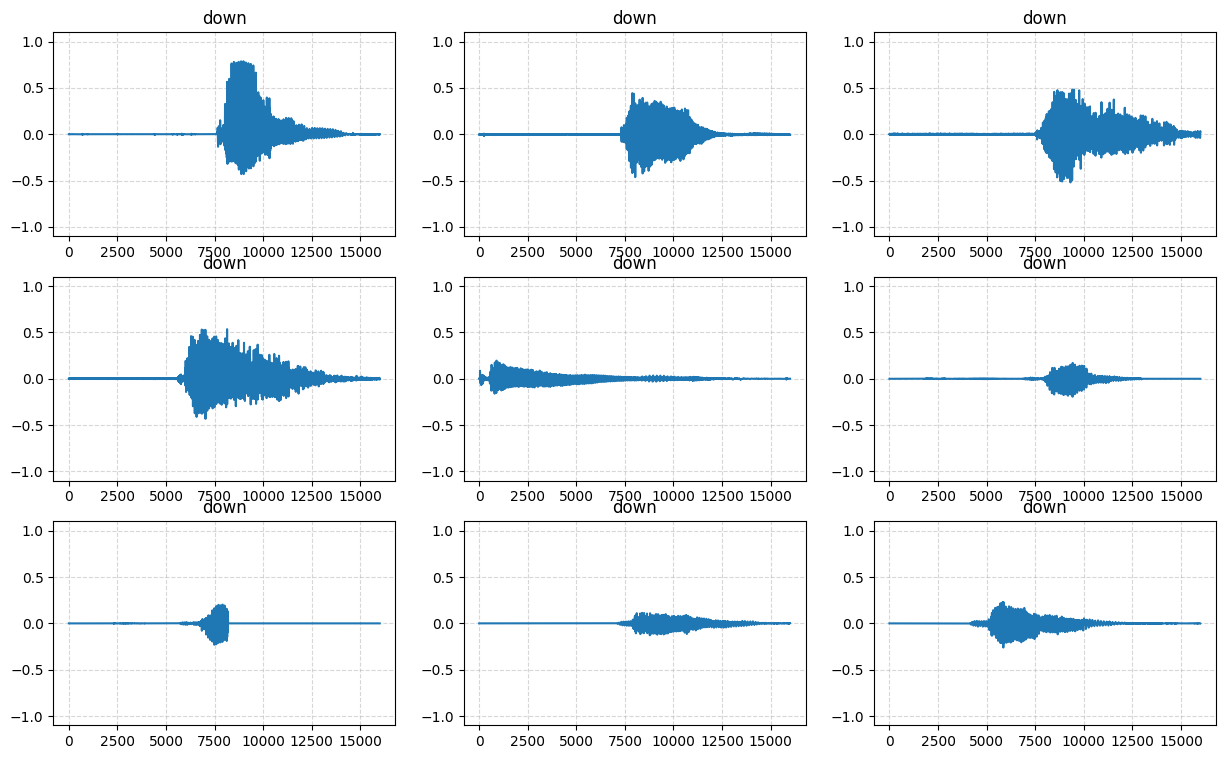

In [13]:
rows = 3
cols = 3
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 9))

# Se realiza el gráfico de los primeros 9 archivos del conjunto de entrenamiento
for i in range(n):
   file_path = train_files[i]
   audio, label = cargar_onda_y_etiqueta(file_path)
   r = i // cols
   c = i % cols
   ax = axes[r][c]
   ax.plot(audio)
   ax.set_ylim(-1.1, 1.1)
   ax.set_title(label)
   ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### Transformación del audio a espectogramas

Los espectrogramas de Mel representan la energía de la señal de audio en función del tiempo (eje horizontal) y la frecuencia en escala Mel (eje vertical). La escala Mel comprime las frecuencias altas y expande las bajas, imitando la percepción auditiva humana.  El color representa la intensidad de energía en decibeles (dB): colores cálidos indican alta energía, colores fríos indican baja energía o silencio.

In [14]:
def audio_a_mel(audio, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max) # escala logaritmica (dB)
    return mel_db # shape: (F, T) = (n_mels, T)

Realizamos la normalización estándar que debe calcularse solo sobre el conjunto de entrenamiento. Para esto procesamos primero los espectogramas para obtener los valores escalares fijos

In [15]:
espectrogramas_train = []

for file in train_files:
    audio, label = cargar_onda_y_etiqueta(file) # Carga el audio a 16kHz y asegura que dure exactamente 1s.
    mel_db = audio_a_mel(audio)                 # Utilizamos la escala mel para comprimir las frecuencias altas y expandir las bajas
    espectrogramas_train.append(mel_db)         

# Calculá la media y desvío global en train
espectrogramas_train = np.array(espectrogramas_train)
mean_train = espectrogramas_train.mean()
std_train = espectrogramas_train.std()

print(f"Media de Train: {mean_train} \nDesvío de Train: {std_train}")

Media de Train: -57.210365295410156 
Desvío de Train: 19.839889526367188


Obtenemos una lista que contiene matrices (una por cada archivo de audio de train_files). Cada una de esas matrices es un Espectrograma de Mel en escala logarítmica (dB) con los siguiente:
- Frecuencia en el eje 0 (Filas): Representa las 64 bandas de frecuencia Mel (la altura de la matriz).  
- Tiempo en el eje 1 (Columnas): Representa los pasos temporales (frames) a lo largo de ese segundo de duración (el ancho de la matriz).  

Además, obtenemos la media -57.21 y el desvío estándar 19.83 del conjunto de entrenamiento.

A continuación realizamos los gráficos de 8 espectogramas (4 instancias de la misma clase y 4 instancias de clases distintas):

In [16]:
clase_down = 'down'
clase_up = 'up'
indices_down = []
indices_up = []

for idx, file_path in enumerate(train_files):
    audio_val, label_val = cargar_onda_y_etiqueta(file_path)
    
    if label_val == clase_down and len(indices_down) < 4:
        indices_down.append(idx)
    elif label_val == clase_up and len(indices_up) < 4:
        indices_up.append(idx)
        
    # Si ya encontramos 4 instancias de cada clase, finalizamos el bucle
    if len(indices_down) == 4 and len(indices_up) == 4:
        break

indices_finales = indices_down + indices_up

En este caso, vamos a visualizar las clases 'down' y 'up' en forma de espectrogramas. Para ello, obtenemos 4 instancias de cada clase y las almacenamos en una lista general de índices finales; a continuación, se presentan los gráficos correspondientes:

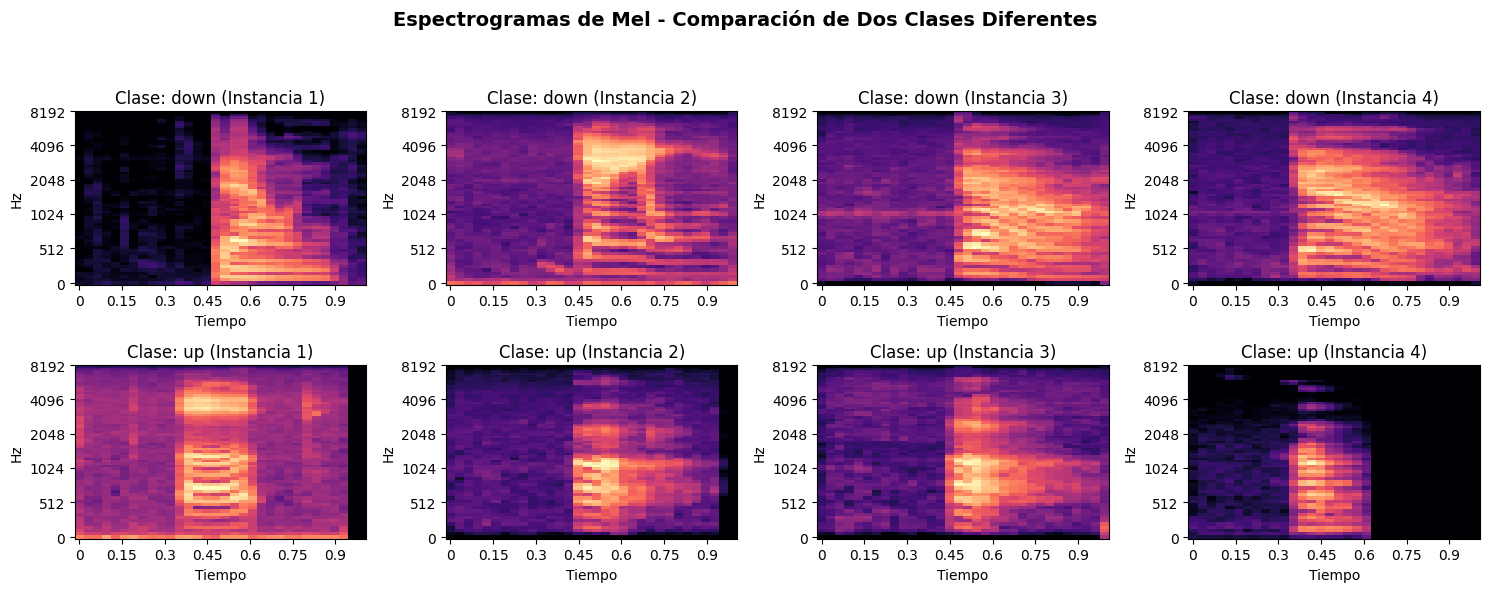

In [17]:
rows = 2
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))

for i, idx_train in enumerate(indices_finales):
    file_path = train_files[idx_train]
    audio, label = cargar_onda_y_etiqueta(file_path)
    spectrogram = espectrogramas_train[idx_train]
    
    # Posición en la grilla
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    
    # Graficar usando librosa.display sobre el objeto 'ax' 
    img = librosa.display.specshow(spectrogram, sr=16000, hop_length=512, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    
    # Título indicando el comando y el número de ejemplo (del 1 al 4)
    ax.set_title(f"Clase: {label} (Instancia {c + 1})")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Hz")

# Título general destacado para el informe
fig.suptitle('Espectrogramas de Mel - Comparación de Dos Clases Diferentes', fontsize=14, fontweight='bold')

# Ajuste inteligente de espacios para evitar superposiciones
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

En la clase down podemos observar que la señal útil dura del 0.45 al final aproximadamente ya que antes son señales débiles. El rango de frecuencia en el que se concentra la energía del comando se mantiene mayormente por debajo de los 2048Hz a 4096Hz, aunque el gráfico muestre el límite de muestreo hasta los 8192Hz. 

En la clase up la señal útil es mucho más corta, estando compactada entre el 0.4 y 0.6 de tiempo, y el rango de frecuencia donde realmente se concentra la energía también es por debajo de los 4096Hz, localizándose con fuerza en el centro de ese intervalo temporal.

Visualmente sí se pueden distinguir espectrogramas de clases distintas a simple vista, ya que down muestra una energía estirada y continua hacia el final, mientras que up se observa como un bloque de energía central y corto que se interrumpe de golpe. Entre espectrogramas de la misma clase se observa una gran similitud, variando levemente según el ritmo o la intensidad del hablante.

#### Segmentación con ventana deslizante

Antes de pasar el espectrograma a la CNN, se divide en ventanas temporales con solapamiento. Cada ventana cubre W columnas del eje temporal y representa una región acústica del audio. El solapamiento garantiza que las transiciones entre sílabas no queden partidas entre dos ventanas sin contexto compartido.

El overlap entre ventanas consecutivas es window_size - hop. Con window size=16 y hop=8 el solapamiento es del 50%, lo que asegura que cada transición fonética aparezca representada en al menos dos ventanas consecutivas

In [18]:
def extraer_ventanas(mel, window_size=16, hop=8):
    """
    mel: array (F, T)
    window_size: ancho de cada ventana en frames temporales
    hop: desplazamiento entre ventanas (hop < window_size -> solapamiento)
    Retorna: array (N, F, window_size) con N ventanas
    """
    F, T = mel.shape
    ventanas = []
    for start in range(0, T - window_size + 1, hop):
        ventana = mel[:, start : start + window_size] # (F, W)
        ventanas.append(ventana)
    return np.stack(ventanas) # (N, F, W)

Nota sobre shapes: El espectrograma tiene shape (F, T) con frecuencia en el eje 0 y tiempo en el eje 1. Cada ventana extraída tiene shape (F, W). Al pasarla a la CNN como imagen monocanal: (1, F, W). Es importante no confundir los ejes: la CNN debe recibir frecuencia en la dimensión de altura e índice de ventana como paso de secuencia para la RNN.

### 4. Arquitectura CRNN
---

Para optimizar el flujo de trabajo y habilitar la ejecución de los diferentes experimentos, se desarrollaron funciones y estructuras genéricas parametrizadas, permitiendo su reutilización en cada bloque experimental sin necesidad de duplicar código estructural. En primera instancia, se diseñó la clase CNNEncoderGenerico, cuya función es procesar de forma independiente cada ventana espectro-temporal para comprimir la matriz de características y devolver un vector latente representativo. Este componente se encarga de recibir dinámicamente la altura del espectrograma, el ancho de la ventana de tiempo, la configuración de los canales y el tamaño del kernel del filtro.El comportamiento operativo y de diseño de este codificador se divide en los siguientes lineamientos:

- Configuración del Bloque Convolucional: A partir del tamaño del filtro se calcula el padding exacto a la mitad (kernel_size/2) para preservar las dimensiones espaciales durante las convoluciones. Cada bloque modular se compone de dos capas de convolución seguidas de Batch Normalization y una función de activación no lineal ReLU. Para maximizar la eficiencia computacional y evitar redundancias, se desactivó el uso de sesgo (bias=False), dado que la normalización por lotes neutraliza su efecto matemático al centrar las medias.
- Reducción Espacial y Submuestreo: Al finalizar cada bloque secuencial se introduce una capa de Max Pooling con una ventana de 2x2 y stride de 2. El algoritmo registra de forma acumulativa cuántas veces se reduce la resolución espacial a la mitad mediante una variable de escala, permitiendo conocer con precisión geométrica las dimensiones remanentes en los ejes de frecuencia y tiempo.
- Proyección e Inicialización: Todos los bloques modulares se almacenan organizados dentro de un contenedor nn.ModuleList. Al concluir la etapa convolucional, el tamaño del mapa de características final se calcula dinámicamente multiplicando los canales de salida residuales por la resolución geométrica remanente. 

Finalmente, el tensor es aplanado y una capa lineal se encarga de proyectar los elementos hacia el espacio dimensional que espera recibir la capa de memoria de la RNN (nn.GRU o nn.LSTM), aplicando una inicialización robusta de pesos mediante la técnica de Kaiming Normal para asegurar la estabilidad de los gradientes.

In [19]:
class CNNEncoderGenerico(nn.Module):
    """
    Procesa una sola ventana (batch, 1, F, W) -> vector (batch, embedding_dim)
    """
    def __init__(self, n_mels=64, window_size=16, config_bloques=[(1, 32), (32, 64)], embedding_dim=128, kernel_size=3):
        """
        n_mels: Altura del espectrograma (F).
        window_size: Ancho de la ventana de tiempo (W).
        config_bloques: Lista de tuplas [(in_ch, out_ch), ...]
        embedding_dim: Dimensión del vector de características de salida (ej. 128) que va a la RNN.
        kernel_size: Tamaño del filtro.
        """
        super().__init__()
        padding = kernel_size // 2 
        bloques = []
        
        # Guardamos cuántas veces se va a reducir la resolución espacial (por cada MaxPool)
        reduccion_espacial = 1
        
        for in_ch, out_ch in config_bloques:
            bloque = nn.Sequential(
                # bias=False ya que BatchNorm neutraliza el bias
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding, bias=False),
                nn.BatchNorm2d(out_ch), 
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=kernel_size, padding=padding, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
            bloques.append(bloque)
            reduccion_espacial *= 2  # Cada bloque tiene un MaxPool2d(2) - reduce a la mitad
            
        self.etapa_convolucional = nn.ModuleList(bloques)
        
        # Cálculo genérico del tamaño de salida
        ultimo_canal_salida = config_bloques[-1][1]
        f_final = n_mels // reduccion_espacial
        w_final = window_size // reduccion_espacial
            
        self.out_size = ultimo_canal_salida * f_final * w_final
        # Capa lineal para proyectar al tamaño que espera recibir la capa GRU/LSTM
        self.fc = nn.Linear(self.out_size, embedding_dim)
        # Inicialización de pesos
        self._init_pesos()

    def _init_pesos(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch * N, 1, F, W)
        for bloque in self.etapa_convolucional:
            x = bloque(x)
        x = x.flatten(1)     # Aplana a (batch * N, out_size)
        return self.fc(x)    # Proyecta a (batch * N, embedding_dim)

Luego, los datos se transfieren a una arquitectura CRNN (Convolutional Recurrent Neural Network) que gestiona las ventanas secuenciales del audio. Con el fin de optimizar el tiempo de cómputo, primero se colapsan las dimensiones del lote (batch) y de las ventanas secuenciales; de esta forma, la CNN puede procesar todas las ventanas en paralelo simultáneamente. 

Tras la extracción de características por parte del codificador genérico, el flujo de datos reestructura la secuencia temporal mediante la operación .view(), adaptando las dimensiones al formato requerido por la capa recurrente (configurable dinámicamente como LSTM o GRU).

Esta capa procesa la secuencia de manera bidireccional (o unidireccional según se configure) para capturar tanto el contexto anterior como el posterior dentro de la palabra. Finalmente, para realizar la clasificación, se extrae únicamente el estado correspondiente al último paso temporal de la secuencia y se proyecta a través de una capa lineal (fully connected) que devuelve las puntuaciones para las 10 clases objetivo.

In [ ]:
class CRNN(nn.Module):
    def __init__(self, n_mels, window_size, n_classes, config_bloques, embedding_dim,  rnn_type, rnn_hidden, rnn_layers,  bidirectional, dropout):
        super().__init__()
        
        # Conectamos con tu encoder genérico
        self.encoder = CNNEncoderGenerico(n_mels=n_mels, window_size=window_size, config_bloques=config_bloques, embedding_dim=embedding_dim)
        
        # Selección dinámica del tipo de capa recurrente y su dirección
        if rnn_type.upper() == "LSTM":
            self.rnn = nn.LSTM(input_size=embedding_dim, hidden_size=rnn_hidden,num_layers=rnn_layers,batch_first=True,bidirectional=bidirectional, dropout=dropout if rnn_layers > 1 else 0.0)
        else:
            self.rnn = nn.GRU(input_size=embedding_dim, hidden_size=rnn_hidden,num_layers=rnn_layers,batch_first=True,bidirectional=bidirectional, dropout=dropout if rnn_layers > 1 else 0.0)
            
        # Ajuste dinámico de la capa lineal según la dirección de la RNN
        num_direcciones = 2 if bidirectional else 1
        self.fc = nn.Linear(rnn_hidden * num_direcciones, n_classes) 
    
    def forward(self, x):
        # x: (batch, N, F, W) -> N ventanas secuenciales de espectrograma
        x = x.unsqueeze(2)                          # (batch, N, 1, F, W)
        batch, N, C, F, W = x.shape                 
        x = x.view(batch * N, C, F, W)              # Colapsa para procesar en paralelo en la CNN
        x = self.encoder(x)                         # Salida: (batch * N, embedding_dim)
        x = x.view(batch, N, -1)                    # Re-arma la secuencia para la RNN (batch, N, embedding_dim)
        x, _ = self.rnn(x)                          # Salida: (batch, N, rnn_hidden * num_direcciones)
        x = x[:, -1, :]                             # Tomamos el último paso temporal
        return self.fc(x)                           # Clasificador (Logits)

### 5. Entrenamiento y experimentos
---

La red neuronal no puede recibir directamente las rutas de texto (paths) de los archivos en disco, ni tampoco es viable procesar los miles de audios del dataset en un solo paso, ya que se superaría la capacidad de memoria de la GPU. Por lo tanto, es indispensable procesar los datos en lotes pequeños (batches) de, por ejemplo, 32 o 64 muestras a la vez.Para resolver esto, implementamos la función obtener_batch. 

Esta función toma un subgrupo de rutas de archivos y se encarga de coordinar todo el pipeline de preprocesamiento desarrollado previamente: realiza la carga del audio, genera el espectrograma Mel y aplica la técnica de ventana deslizante. Finalmente, mapea la etiqueta de texto del comando a su correspondiente índice numérico mediante un diccionario (label_to_idx) y empaqueta todo devolviendo los tensores X (características) e Y (etiquetas).

In [21]:
label_to_idx = {word: i for i, word in enumerate(commands)}                                         # Diccionario para pasar los comandos de texto a números (índices)

def obtener_batch(lista_paths_subgrupo, config):
    """
    Toma una lista pequeña de paths (un lote) y devuelve los tensores X e Y dinámicamente
    """
    batch_x = []
    batch_y = []
    
    for path in lista_paths_subgrupo:
        audio, label_texto = cargar_onda_y_etiqueta(path)                                           # Carga el audio
        mel_db = audio_a_mel(audio)                                                                 # Genera el espectograma
        ventanas = extraer_ventanas(mel_db, window_size=config['window_size'], hop=config['hop'])   # Activa la ventana deslizante
        label_numerico = label_to_idx[label_texto]                                                  # Convierte el texto a número usando el diccionario

        # Guardamos en nuestras listas del lote
        batch_x.append(ventanas)
        batch_y.append(label_numerico)
    
    # Convertimos las listas de NumPy a Tensores de PyTorch
    # batch_x original es una lista de arrays de shape (N, F, W) -> al apilar queda (Batch_Size, N, F, W)
    x_tensor = torch.tensor(np.stack(batch_x), dtype=torch.float32)
    y_tensor = torch.tensor(batch_y, dtype=torch.long)
    
    return x_tensor, y_tensor

Se configuró la selección dinámica del dispositivo de cómputo (device). El script verifica si el entorno cuenta con soporte para CUDA (lo que permite aprovechar la aceleración por hardware de una GPU de NVIDIA). De estar disponible, el modelo y los tensores se transfieren a la GPU para reducir drásticamente los tiempos de entrenamiento; de lo contrario, el sistema conmuta automáticamente al uso de la CPU, asegurando que el código sea ejecutable en cualquier computadora.

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")

Entrenando en el dispositivo: cpu


Para llevar a cabo el entrenamiento y la evaluación de los distintos experimentos de forma sistemática, se desarrolló una función genérica y manual adaptado para configuraciones dinámicas.

A lo largo de las épocas, la función registra el progreso del modelo almacenando las métricas de pérdida (loss) y precisión (accuracy), tanto para el conjunto de entrenamiento como para el de validación, en un diccionario de historial. En cada iteración, los datos se procesan mediante los lotes (batches) generados dinámicamente en el paso previo, transfiriendo los tensores al dispositivo activo (CPU o GPU) para ejecutar los pases hacia adelante (forward pass) y hacia atrás (backward pass), junto con un recorte de gradientes (gradient clipping) para estabilizar la optimización.

Con el propósito de no saturar la salida de la consola, el progreso visual se reporta de forma controlada cada 5 épocas, o bien de manera inmediata cada vez que el modelo alcanza una mejora en el conjunto de validación. Finalmente, se incorporó un mecanismo de parada temprana (early stopping) basado en un umbral de paciencia configurable: si la pérdida de validación no disminuye durante un número determinado de épocas consecutivas, el proceso se detiene automáticamente, protegiendo al modelo contra el sobreajuste (overfitting) y restaurando los mejores pesos guardados hasta ese momento

In [ ]:
def loop_entrenamiento_crnn_manual(modelo, train_files, val_files, criterio, optimizador, scheduler, config, device=device, nombre='CRNN'):
    """
    Loop de entrenamiento genérico adaptado para experimentos dinámicos.
    """
    historial = {'train_loss': [], 'val_loss': [], 'train_acc':  [], 'val_acc':  [],}

    mejor_val_loss = float('inf')
    mejor_pesos = None
    espera = 0

    # Leemos epochs y patience desde el diccionario config para el print
    print(f"\nEntrenando {nombre} | epochs={config['epochs']} | patience={config['patience']}")
    print(f"   {'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train Acc':>10} | {'Val Acc':>9} | {'LR':>8}")
    print("   " + "─"*62)

    for epoca in range(1, config['epochs'] + 1):
        modelo.train()
        train_loss_total = 0.0   
        train_correctos  = 0     
        train_total      = 0     

        random.shuffle(train_files)
        
        for i in range(0, len(train_files), config['batch_size']):
            paths_del_lote = train_files[i : i + config['batch_size']]
            
            if len(paths_del_lote) < config['batch_size']:
                continue

            X_batch, y_batch = obtener_batch(paths_del_lote, config)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            logits = modelo(X_batch)
            loss = criterio(logits, y_batch)

            # Backward pass
            optimizador.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizador.step()

            train_loss_total += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            train_correctos += (preds == y_batch).sum().item()
            train_total += X_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc  = train_correctos  / train_total

        modelo.eval()
        val_loss_total = 0.0
        val_correctos  = 0
        val_total      = 0

        with torch.no_grad():
            for i in range(0, len(val_files), config['batch_size']):
                paths_del_lote = val_files[i : i + config['batch_size']]
                
                if len(paths_del_lote) < config['batch_size']:
                    continue

                X_val, y_val = obtener_batch(paths_del_lote, config)
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                
                logits_v = modelo(X_val)
                loss_v  = criterio(logits_v, y_val)
                
                preds_v = logits_v.argmax(dim=1)
                val_correctos += (preds_v == y_val).sum().item()
                val_loss_total += loss_v.item() * X_val.size(0)
                val_total      += X_val.size(0)

        val_loss = val_loss_total / val_total
        val_acc  = val_correctos  / val_total

        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        # Scheduler y Early Stopping
        lr_actual = optimizador.param_groups[0]['lr']
        scheduler.step(val_loss)

        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0   
            
            torch.save({
                'epoch': epoca,
                'model_state_dict': mejor_pesos,
                'val_loss': mejor_val_loss,
                'val_acc': val_acc
            }, f"best_model_{config['nombre']}.pth")
        else:
            espera += 1  

        if epoca % 5 == 0 or espera == 0:
            print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                  f"{train_acc:10.4f} | {val_acc:9.4f} | {lr_actual:.2e}")

        if espera >= config['patience']:
            break

    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)

    return historial

Además, se desarrolló la función evaluar_precision_test, cuyo propósito es medir el desempeño final y la capacidad de generalización del modelo utilizando el conjunto de datos de prueba. Esta función configura el modelo en modo de evaluación y envuelve el proceso en un bloque torch.no_grad() para desactivar el cálculo de gradientes y la retención de gráficos intermedios, lo que reduce significativamente el consumo de memoria y acelera la inferencia. Los datos de prueba se procesan de forma iterativa y dinámica en lotes (batches) adaptados a la configuración de cada experimento Finalmente, se calcula la precisión global (accuracy) comparando las predicciones del modelo con las etiquetas reales. 

In [51]:
def evaluar_precision_test(modelo, test_files, config, device=device):
    """
    Evalúa la precisión del modelo en el conjunto de test usando la estrategia
    manual de obtener_batch basada en las rutas de los archivos y la configuración actual.
    """
    modelo.eval() # Modo evaluación
    correctas = 0
    total = 0
    batch_size = config.get('batch_size', 32)
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes
        # Iteramos manualmente sobre la lista de test usando tu función dinámica
        for i in range(0, len(test_files), batch_size):
            paths_del_lote = test_files[i : i + batch_size]
            
            # Saltamos el último lote si está incompleto para mantener la consistencia
            if len(paths_del_lote) < batch_size:
                continue
                
            X_batch, y_batch = obtener_batch(paths_del_lote, config)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)
            
            correctas += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
    return (correctas / total) * 100

Por último, se implementó una función de visualización para graficar las curvas de pérdida (loss) y precisión (accuracy) de entrenamiento y validación. 

In [ ]:
def graficar_curvas(historial, nombre_experimento):
    epochs = range(1, len(historial['train_loss']) + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='red', linestyle='--')
    plt.title(f'Pérdida - {nombre_experimento}')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Gráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['train_acc'], label='Train Acc', color='blue')
    plt.plot(epochs, historial['val_acc'], label='Val Acc', color='red', linestyle='--')
    plt.title(f'Accuracy - {nombre_experimento}')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

#### Experimento 1

Para el primer experimento se estableció una arquitectura de referencia orientada a capturar la estructura secuencial del audio mediante celdas recurrentes bidireccionales y un codificador convolucional de dos etapas. Los parámetros clave seleccionados para esta prueba inicial se detallan a continuación:
- Ventana Deslizante: Tamaño de ventana de 16 frames con un solapamiento (hop) de 8 frames.
- Codificador Convolucional (CNN): Compuesto por dos bloques convolucionales. El primero transforma el canal de entrada inicial a 32 mapas de características, y el segundo profundiza la extracción pasando de 32 a 64 canales, proyectando finalmente las características a una dimensión de embedding de 128.
- Capa Recurrente (RNN): Se configuró una red GRU Bidireccional de 2 capas con 128 unidades ocultas y un dropout intercapa de 0.3 para mitigar el sobreajuste.
- Se fijó una tasa de aprendizaje (learning rate) inicial de 0.001 utilizando el optimizador Adam y la función de pérdida de Entropía Cruzada (Cross-Entropy Loss) para las 10 clases objetivo. 
- El tamaño del lote se estableció en 32 muestras lo largo de un máximo de 15 épocas.
- Para gestionar dinámicamente la tasa de aprendizaje durante el entrenamiento, se acopló el planificador ReduceLROnPlateau (configurado con un factor de reducción de 0.5 y una paciencia de 3 épocas). 
- Se aplicó una parada temprana (early stopping) con una paciencia estricta de 5 épocas. 

Todos los históricos de pérdidas y precisiones fueron almacenados con el identificador "E1" para su posterior consolidación en la tabla comparativa.

In [ ]:
config_e1 = {
    "nombre": "E1",
    "window_size": 16,
    "hop": 8,
    "config_bloques": [(1, 32), (32, 64)],
    "embedding_dim": 128,
    "rnn_type": "GRU",
    "rnn_hidden": 128,
    "rnn_layers": 2,
    "bidirectional": True,
    "dropout": 0.3,
    "batch_size": 32,
    "epochs": 15,
    "patience": 5,
    "lr": 0.001}

model_e1 = CRNN(
    n_mels=64, window_size=config_e1['window_size'], n_classes=10,
    config_bloques=config_e1['config_bloques'], embedding_dim=config_e1['embedding_dim'],
    rnn_type=config_e1['rnn_type'], rnn_hidden=config_e1['rnn_hidden'], rnn_layers=config_e1['rnn_layers'],
    bidirectional=config_e1['bidirectional'], dropout=config_e1['dropout']).to(device)

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(model_e1.parameters(), lr=config_e1['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=3)

historial_e1 = loop_entrenamiento_crnn_manual(
    modelo=model_e1,
    train_files=train_files,
    val_files=val_files,
    criterio=criterio,
    optimizador=optimizador,
    scheduler=scheduler,
    config=config_e1,
    device=device,
    nombre=config_e1['nombre'])


Entrenando E1 | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     0.7946 |     0.3501 |     0.7203 |    0.8829 | 1.00e-03
        2 |     0.3385 |     0.2748 |     0.8883 |    0.9073 | 1.00e-03
        3 |     0.2762 |     0.2728 |     0.9081 |    0.9092 | 1.00e-03
        5 |     0.2180 |     0.2328 |     0.9287 |    0.9264 | 1.00e-03
        6 |     0.2027 |     0.2158 |     0.9341 |    0.9313 | 1.00e-03
        7 |     0.1885 |     0.2041 |     0.9402 |    0.9383 | 1.00e-03
        8 |     0.1780 |     0.1962 |     0.9418 |    0.9372 | 1.00e-03
       10 |     0.1675 |     0.2090 |     0.9448 |    0.9416 | 1.00e-03
       13 |     0.1113 |     0.1699 |     0.9636 |    0.9535 | 5.00e-04
       15 |     0.0899 |     0.1773 |     0.9705 |    0.9530 | 5.00e-04


In [37]:
acc_test_e1 = evaluar_precision_test(
     modelo=model_e1, 
     test_files=test_files, 
     config=config_e1, 
     batch_size=config_e1['batch_size'], 
     device=device
)
print(f"Precisión en Test: {acc_test_e1:.2f}%")

Precisión en Test: 95.30%


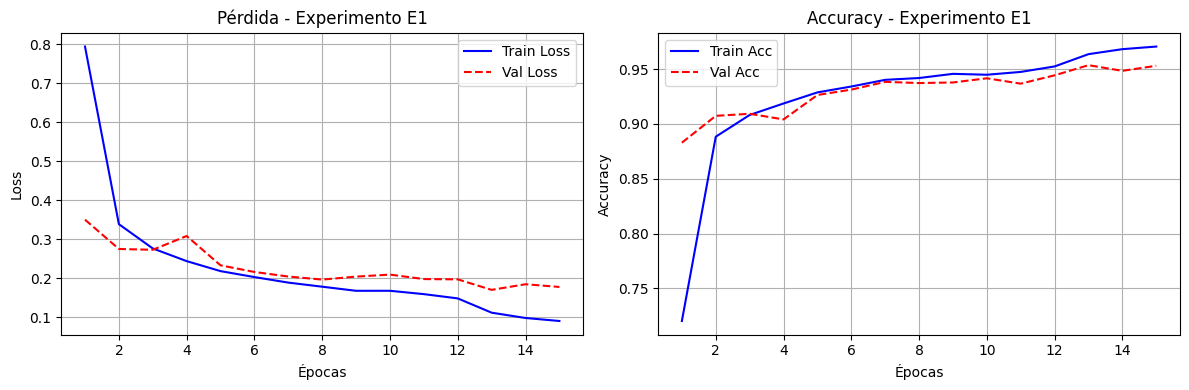

In [ ]:
graficar_curvas(historial_e1, 'Experimento E1')

El experimento 1 funcionó exitosamente demostrando que en cada época se reduce el train loss y aumenta el accuracy. Por otro lado, la precisión en test es del 95.30%, lo cual es un valor muy elevado y nos dice que el modelo aprendió correctamente a generalizar con datos nuevos.

Además, al observar el gráfico de pérdida, notamos que en train va descendiendo gradualmente mientras que en accuracy va mejorando su valor en cada ejecución. Si bien val loss y val acc tienen unos pequeños picos (debido a la oscilación normal del aprendizaje), en ambos gráficos se ve claramente que siempre van tendiendo al mejor resultado. Con este análisis podemos concluir que el primer experimento funciona de manera muy eficiente evitando el sobreajuste (overfitting), ya que las curvas de train y validation se mantienen muy cerca la una de la otra hasta el final.

#### Experimento 2

Para el segundo experimento se modificó la arquitectura con los siguientes parámetros:
- Ventana Deslizante: Se redujo el tamaño de ventana a 8 frames con un solapamiento (hop) de 4 frames. Al ser ventanas más estrechas, se genera una secuencia temporal más larga y con mayor redundancia para que procese la capa recurrente.
- Codificador Convolucional (CNN): Se mantuvo idéntico al experimento anterior, compuesto por dos bloques convolucionales. El primero transforma el canal de entrada inicial a 32 mapas de características, y el segundo profundiza la extracción pasando de 32 a 64 canales, proyectando finalmente las características a una dimensión de embedding de 128.
- Capa Recurrente (RNN): En lugar de celdas GRU, se configuró una red LSTM Bidireccional de 2 capas con 128 unidades ocultas.
- Se incrementó ligeramente el dropout intercapa a 0.4.
- Se fijó una tasa de aprendizaje (learning rate) inicial de 0.001 utilizando el optimizador Adam y la función de pérdida de Entropía Cruzada (Cross-Entropy Loss) para las 10 clases objetivo.
- El tamaño del lote se estableció en 32 muestras a lo largo de un máximo de 15 épocas.

Para gestionar la tasa de aprendizaje durante el entrenamiento se acopló el planificador ReduceLROnPlateau (configurado con un factor de reducción de 0.5 y una paciencia de 3 épocas). Asimismo, se aplicó una parada temprana (early stopping) con una paciencia de 5 épocas.

In [ ]:
config_e2 = {
    "nombre": "E2",
    "window_size": 8,           
    "hop": 4,                   
    "config_bloques": [(1, 32), (32, 64)],
    "embedding_dim": 128,
    "rnn_type": "LSTM",         
    "rnn_hidden": 128,
    "rnn_layers": 2,
    "bidirectional": True,      
    "dropout": 0.4,             
    "batch_size": 32,
    "epochs": 15,               
    "patience": 5,
    "lr": 0.001
}

model_e2 = CRNN(
    n_mels=64, window_size=config_e2['window_size'], n_classes=10, config_bloques=config_e2['config_bloques'], embedding_dim=config_e2['embedding_dim'],
    rnn_type=config_e2['rnn_type'], rnn_hidden=config_e2['rnn_hidden'], rnn_layers=config_e2['rnn_layers'], bidirectional=config_e2['bidirectional'],
    dropout=config_e2['dropout']).to(device)

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(model_e2.parameters(), lr=config_e2['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=3)

historial_e2 = loop_entrenamiento_crnn_manual(
    modelo=model_e2,
    train_files=train_files,
    val_files=val_files,
    criterio=criterio,
    optimizador=optimizador,
    scheduler=scheduler,
    config=config_e2,
    device=device,
    nombre=config_e2['nombre'])


Entrenando E2 | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     0.8783 |     0.3889 |     0.6881 |    0.8696 | 1.00e-03
        2 |     0.3814 |     0.3042 |     0.8719 |    0.8992 | 1.00e-03
        3 |     0.2937 |     0.2669 |     0.9028 |    0.9141 | 1.00e-03
        4 |     0.2525 |     0.2313 |     0.9163 |    0.9283 | 1.00e-03
        5 |     0.2350 |     0.2322 |     0.9217 |    0.9255 | 1.00e-03
        8 |     0.1881 |     0.1883 |     0.9372 |    0.9427 | 1.00e-03
       10 |     0.1711 |     0.1868 |     0.9427 |    0.9410 | 1.00e-03
       12 |     0.1580 |     0.1808 |     0.9477 |    0.9451 | 1.00e-03
       15 |     0.1400 |     0.1603 |     0.9531 |    0.9511 | 1.00e-03


In [40]:
acc_test_e2 = evaluar_precision_test(
     modelo=model_e2, 
     test_files=test_files, 
     config=config_e2, 
     batch_size=config_e2['batch_size'], 
     device=device
)
print(f"Precisión en Test: {acc_test_e2:.2f}%")

Precisión en Test: 94.88%


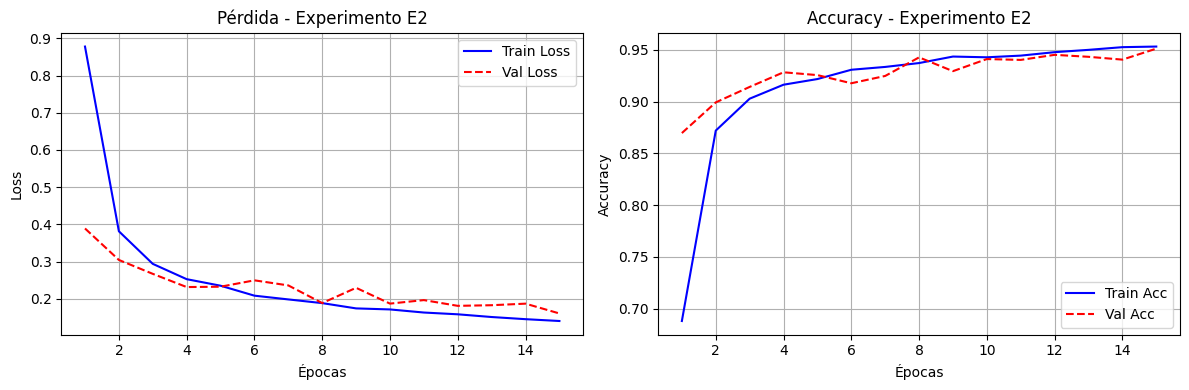

In [ ]:
graficar_curvas(historial_e2, 'Experimento E2')

Podemos observar que por época siempre se fue reduciendo tanto el valor de la pérdida como aumentando el accuracy de entrenamiento. Este modelo obtuvo una precisión en test del 94.88%. si bien es ligeramente menor a la del experimento 1, sigue siendo un valor sumamente alto que demuestra un rendimiento excelente.

Al observar las gráficas, notamos un comportamiento muy parejo y similar al primer experimento, donde la pérdida va decreciendo progresivamente y el accuracy aumenta en cada época de forma constante. Un dato interesante a destacar es que, a diferencia del caso anterior, el optimizador no requirió reducir la tasa de aprendizaje (learning rate), manteniéndose estable en 0.001 durante las 15 épocas. Los pequeños picos u oscilaciones de las curvas de validación se corrigieron rápidamente por sí solos en las épocas siguientes. Con esto concluimos que el cambio a celdas LSTM junto con una ventana más estrecha de 8 frames es una alternativa muy sólida y eficiente que también logra evitar por completo el sobreajuste (overfitting).

#### Experimento 3

Para el tercer y último experimento se modificó la arquitectura con los siguientes parámetros:
- Ventana Deslizante: Se incrementó el tamaño de ventana a 32 frames con un solapamiento (hop) de 16 frames. Al ensanchar las ventanas, se le otorga un mayor contexto local a la CNN, produciendo a su vez secuencias temporales más cortas para la capa recurrente.
- Codificador Convolucional (CNN): Se aumentó la complejidad del encoder duplicando la cantidad de filtros por capa. El primer bloque convolucional transforma el canal de entrada a 64 mapas de características y el segundo profundiza la extracción pasando de 64 a 128 canales, proyectando los resultados a una dimensión de embedding más robusta de 256.
- Capa Recurrente (RNN): Se retornó al tipo de celda GRU Bidireccional con 2 capas, pero expandiendo el número de unidades ocultas a 256. Para observar el comportamiento puro de la red con esta capacidad, se removió el dropout intercapa configurándolo en 0.0.
- A diferencia de los experimentos previos, se fijó una tasa de aprendizaje (learning rate) inicial más conservadora de 0.0001, utilizando el optimizador Adam y la función de pérdida de Entropía Cruzada (Cross-Entropy Loss).
- El tamaño del lote se mantuvo en 32 muestras a lo largo de un máximo de 15 épocas.
- Se acopló el planificador ReduceLROnPlateau (configurado con un factor de reducción de 0.5 y una paciencia de 3 épocas) y una parada temprana (early stopping) con una paciencia de 5 épocas.

In [53]:
config_e3 = {
    "nombre": "E3",
    "window_size": 32,          
    "hop": 16,                  
    "config_bloques": [(1, 64), (64, 128)], 
    "embedding_dim": 256,       
    "rnn_type": "GRU",          
    "rnn_hidden": 256,          
    "rnn_layers": 2,
    "bidirectional": False,
    "dropout": 0.0,             
    "batch_size": 32,
    "epochs": 15,
    "patience": 5,
    "lr": 0.0001
}

model_e3 = CRNN(
    n_mels=64,window_size=config_e3['window_size'], n_classes=10, config_bloques=config_e3['config_bloques'], embedding_dim=config_e3['embedding_dim'],
    rnn_type=config_e3['rnn_type'], rnn_hidden=config_e3['rnn_hidden'], rnn_layers=config_e3['rnn_layers'], bidirectional=config_e3['bidirectional'],
    dropout=config_e3['dropout']).to(device)

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(model_e3.parameters(), lr=config_e3['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=3)

historial_e3 = loop_entrenamiento_crnn_manual(
    modelo=model_e3,
    train_files=train_files,
    val_files=val_files,
    criterio=criterio,
    optimizador=optimizador,
    scheduler=scheduler,
    config=config_e3,
    device=device,
    nombre=config_e3['nombre'])


Entrenando E3 | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     0.8649 |     0.4248 |     0.7271 |    0.8633 | 1.00e-04
        2 |     0.3211 |     0.3808 |     0.8963 |    0.8709 | 1.00e-04
        3 |     0.2385 |     0.2396 |     0.9202 |    0.9177 | 1.00e-04
        5 |     0.1606 |     0.2545 |     0.9448 |    0.9168 | 1.00e-04
        6 |     0.1323 |     0.2351 |     0.9539 |    0.9280 | 1.00e-04
       10 |     0.0689 |     0.2881 |     0.9759 |    0.9307 | 1.00e-04


In [57]:
acc_test_e3 = evaluar_precision_test(
     modelo=model_e3, 
     test_files=test_files, 
     config=config_e3, 
     device=device
)
print(f"Precisión en Test: {acc_test_e3:.2f}%")

Precisión en Test: 92.94%


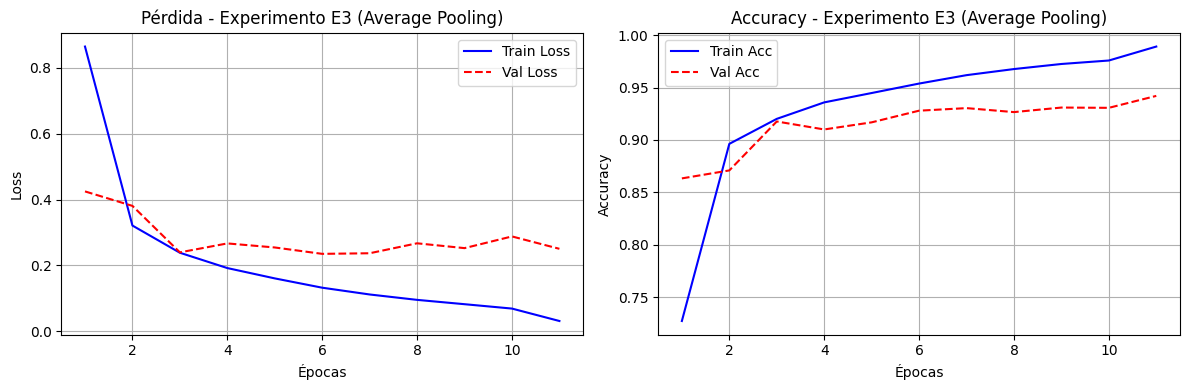

In [58]:
graficar_curvas(historial_e3, 'Experimento E3 (Average Pooling)')

Podemos observar que por época siempre se fue reduciendo tanto el valor de la pérdida (loss) como aumentando el accuracy de entrenamiento. Este modelo obtuvo una precisión en test del 92.94%. si bien es menor a la de los experimentos anteriores, sigue representando un buen rendimiento para la clasificación.

Al observar las gráficas, notamos que en train la pérdida va decreciendo progresivamente y el accuracy aumenta en cada época de forma constante. Sin embargo, las curvas de validación presentan oscilaciones y picos más marcados que en los casos previos. Esto se debe a que, al remover el dropout (0.0), el modelo se vuelve más sensible a las variaciones del conjunto de validación.

Un dato muy importante a destacar es que el entrenamiento se detuvo automáticamente debido a la función de parada temprana (early stopping), ya que el mejor valor de val loss se alcanzó en la época 6 (0.2351) y no volvió a mejorar tras cumplirse la paciencia de 5 épocas.

### 6. Reporte y metricas
---

In [59]:
# Generamos la tabla comparativa de los experimentos
datos_tabla = {
    'Experimento': ['E1', 'E2', 'E3'],
    'CNN': ['', '', ''],
    'Ventana': [None, None, None],
    '(W, RNN, HOP)': ['', '', ''],
    'Acc. val': [None, None, None],
    'Acc. test': [None, None, None],
    'Observaciones': ['', '', '']
}

# Creamos el DataFrame
df_experimentos = pd.DataFrame(datos_tabla)

In [64]:
# Extraemos las mejores precisiones de validación de los experimentos
acc_val_final_e1 = max(historial_e1['val_acc']) * 100
acc_val_final_e2 = max(historial_e2['val_acc']) * 100
acc_val_final_e3 = max(historial_e3['val_acc']) * 100

datos_tabla = {
    'Experimento': ['E1', 'E2', 'E3'],
    'CNN': ['[(1,32), (32,64)]', '[(1,16), (16,32), (32,64)]', '[(1,64), (64,128)]'],
    'Ventana': [16, 8, 32],
    '(W, RNN, HOP)': ['(16, Bi-GRU, 8)', '(8, Bi-LSTM, 4)', '(32, Bi-GRU, 16)'],
    'Acc. val': [f"{acc_val_final_e1:.2f}%", f"{acc_val_final_e2:.2f}%", f"{acc_val_final_e3:.2f}%"],
    'Acc. test': [f"{acc_test_e1:.2f}%", f"{acc_test_e2:.2f}%", f"{acc_test_e3:.2f}%"],
    'Observaciones': [
        'Modelo base robusto. Mejor rendimiento general.',
        'Ventana estrecha y mayor regularización.',
        'Ventana ancha, mayor capacidad y Average Pooling.']}

In [65]:
df_experimentos = pd.DataFrame(datos_tabla)
df_experimentos

,Experimento,CNN,Ventana,"(W, RNN, HOP)",Acc. val,Acc. test,Observaciones
0,E1,"[(1,32), (32,64)]",16,"(16, Bi-GRU, 8)",95.35%,95.30%,Modelo base robusto. Mejor rendimiento general.
1,E2,"[(1,16), (16,32), (32,64)]",8,"(8, Bi-LSTM, 4)",95.11%,94.88%,Ventana estrecha y mayor regularización.
2,E3,"[(1,64), (64,128)]",32,"(32, Bi-GRU, 16)",94.21%,92.94%,"Ventana ancha, mayor capacidad y Average Pooling."


Podemos observar de la tabla comparativa que el modelo que mejor resultado dio respecto a la métrica de accuracy (precisión), tanto en validación con un 95.35% como en el conjunto de prueba (test) con un 95.30%, fue el Experimento 1. Al demostrar la mayor capacidad de generalización y un comportamiento sumamente estable, este diseño se consolida como nuestra arquitectura óptima. Por lo tanto, a continuación realizaremos el análisis de la matriz de confusión utilizando el mejor modelo.

#### Matriz de confusión en el conjunto de test

In [ ]:
all_preds = []
all_labels = []

model_e1.eval()
batch_size = config_e1['batch_size']

with torch.no_grad():
    # Recorremos manualmente tu lista oficial de archivos de test
    for i in range(0, len(test_files), batch_size):
        paths_del_lote = test_files[i : i + batch_size]
        
        # Saltamos el último lote si está incompleto para no deformar las matrices
        if len(paths_del_lote) < batch_size:
            continue
            
        # Generamos el batch usando las ventanas dinámicas del Experimento 1
        X_batch, y_batch = obtener_batch(paths_del_lote, config_e1)
        
        # Movemos al dispositivo detectado (cpu o cuda)
        X_batch = X_batch.to(device)
        
        # FORWARD PASS: Usamos el modelo e1 de forma consistente
        logits = model_e1(X_batch)
        preds = logits.argmax(dim=1)
        
        # Guardamos los resultados pasando todo a la CPU y a formato NumPy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Convertimos las listas recolectadas a arrays de NumPy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

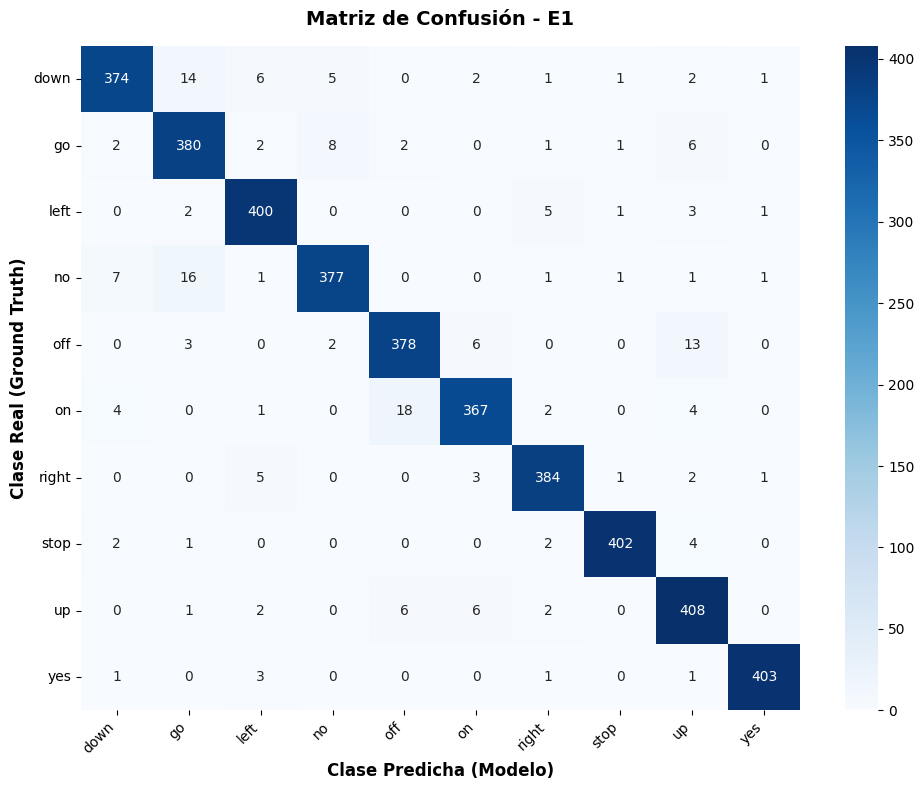

In [ ]:
# Calculamos la matriz de confusión de Scikit-Learn
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
    annot=True,                     # Muestra los números adentro de cada cuadrado
    fmt='d',                        # Formato de enteros
    cmap='Blues', xticklabels=commands, yticklabels=commands)

plt.title(f"Matriz de Confusión - {config_e1['nombre']}", fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Clase Real (Ground Truth)', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha (Modelo)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Al analizar la matriz de confusión del Experimento 1, podemos observar que el modelo predice correctamente en casi todos los casos los 10 comandos, concentrando la gran mayoría de las muestras sobre la diagonal principal. Sin embargo, es posible notar algunas confusiones específicas entre ciertas palabras:
- no vs. go: En 16 casos el comando real 'no' fue clasificado como 'go', y en 8 ocasiones ocurrió lo inverso. Esto se debe a que fonéticamente son palabras monosílabas muy parecidas en su estructura de pronunciación y espectro acústico.
- on vs. off: Se registraron 18 casos donde el comando real 'on' fue confundido con 'off'. Al ser términos opuestos de longitud similar que comparten un contexto de uso idéntico, sus dinámicas temporales suelen ser muy cercanas.
- off vs. up: En 13 casos el comando real 'off' fue predicho erróneamente como 'up', evidenciando otra pequeña confusión fonética en la transición de las vocales iniciales de ambos términos.
- down vs. go: Se observa también que en 14 ocasiones el modelo confundió 'down' con 'go'.

Fuera de estos escenarios puntuales, los errores restantes se presentan en una menor medida. Con este análisis podemos concluir que los pocos fallos del modelo no se deben a problemas de arquitectura, sino a la similitud fonética intrínseca de los comandos de voz seleccionados.

#### Ejemplos de predicciones correctas e incorrectas con la imagen (la clase real y la clase predicha)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7036\802094119.py:83: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7036\802094119.py:83: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


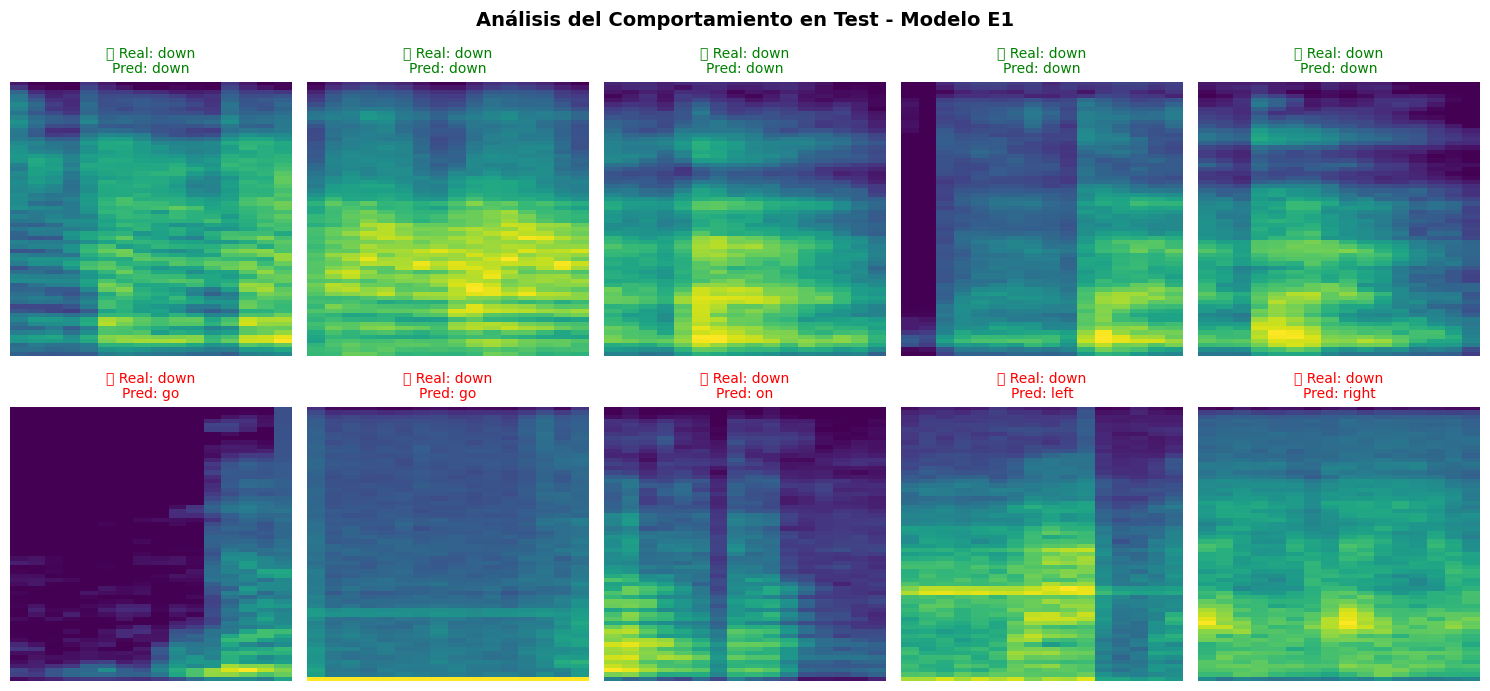

In [ ]:
model_e1.eval()
ejemplos_ok = []
etiquetas_reales_ok = []
predicciones_modelo_ok = []
ejemplos_error = []
etiquetas_reales_error = []
predicciones_modelo_error = []
batch_size = config_e1['batch_size']

with torch.no_grad():
    for i in range(0, len(test_files), batch_size):
        paths_del_lote = test_files[i : i + batch_size]
        
        if len(paths_del_lote) < batch_size:
            continue
            
        # Generamos el lote con las ventanas
        X_batch, y_batch = obtener_batch(paths_del_lote, config_e1)
        X_batch_dev = X_batch.to(device)
        
        logits = model_e1(X_batch_dev)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = y_batch.numpy()
        
        for j in range(len(labels)):
            clase_real = commands[labels[j]]       
            clase_pred = commands[preds[j]]         
            
            # Guardamos si el modelo predijo correctamente
            if labels[j] == preds[j]:
                if len(ejemplos_ok) < 5:
                    # Guardamos la muestra completa
                    ejemplos_ok.append(X_batch[j].numpy())
                    etiquetas_reales_ok.append(clase_real)
                    predicciones_modelo_ok.append(clase_pred)
            
            # Guardamos si el modelo falló
            else:
                if len(ejemplos_error) < 5:
                    ejemplos_error.append(X_batch[j].numpy())
                    etiquetas_reales_error.append(clase_real)
                    predicciones_modelo_error.append(clase_pred)
                    
        # Cortamos el bucle cuando ambas listas tengan los 5 ejemplos requeridos
        if len(ejemplos_ok) >= 5 and len(ejemplos_error) >= 5:
            break

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i in range(5):
    ax = axes[0, i]
    if i < len(ejemplos_ok):
        espectrograma_visual = np.mean(ejemplos_ok[i], axis=0) # Queda de tamaño (F, W)
        im = ax.imshow(espectrograma_visual, aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f"✅ Real: {etiquetas_reales_ok[i]}\nPred: {predicciones_modelo_ok[i]}", fontsize=10, color='green')
    ax.axis('off')

# Predicciones Incorrectas
for i in range(5):
    ax = axes[1, i]
    if i < len(ejemplos_error):
        espectrograma_visual = np.mean(ejemplos_error[i], axis=0)
        im = ax.imshow(espectrograma_visual, aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f"❌ Real: {etiquetas_reales_error[i]}\nPred: {predicciones_modelo_error[i]}", fontsize=10, color='red')
    ax.axis('off')

plt.suptitle(f"Análisis del Comportamiento en Test - Modelo {config_e1['nombre']}", y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Conclusión
---

En este trabajo práctico aprendimos a implementar un análisis profundo sobre archivos de audio, visualizando sus espectrogramas Mel y aplicando técnicas de normalización temporal, como el recorte y el padding, para garantizar que todas las muestras midieran exactamente un segundo de duración.

A lo largo de la experimentación con los 10 comandos de voz, pudimos observar que, si bien algunos términos presentaban una tendencia natural a confundirse debido a sus similitudes fonéticas, el diseño de una estructura robusta (como la arquitectura CRNN optimizada) permite lograr un entrenamiento altamente eficiente, alcanzando predicciones correctas en la gran mayoría de los casos.

El desarrollo de este tipo de modelos resulta sumamente útil en el ámbito del reconocimiento de voz (Speech Recognition) y el procesamiento de lenguaje natural. Su implementación es clave para el diseño de asistentes virtuales inteligentes, sistemas de control por comandos de voz en dispositivos de hardware o interfaces de accesibilidad, demostrando el enorme potencial de combinar redes convolucionales y recurrentes para interpretar información acústica.